# 🚙 **Разработка интеллектуальной системы оценки для «AutoValue AI»**

Автор: Якунин Михаил

Дата: ____ август 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint16_Predictive_Model_Car_Prices.git***

## Цель проекта

## Задача проекта

## Описание данных

## Содержание <a id="content"></a>

* [1. Импорт библиотек и загрузка данных](#1)
  * [1.1. Подготовка среды и библиотек](#1_1)
  * [1.2. Загрузка данных и первичная информация о данных](#1_2)
  * [1.3. Промежуточный итог](#1_3)
* [2. Исследовательский анализ данных (EDA)](#2)
  * [2.1. Анализ целевой переменной (price_rub)](#2_1)
  * [2.2. Анализ числовых признаков](#2_2)
  * [2.3. Анализ категориальных признаков](#2_3)
  * [2.4. Анализ корреляционной матрицы](#2_4)
* [3. Предобработка данных](#3)
  * [3.1. ](#3.1)


## [Этап 1. Импорт библиотек и загрузка данных <a id=1></a>](#content)

### [1.1 Подготовка среды и библиотек <a id=1_1></a>](#content)

In [1]:
# Установка необходимых библиотек
# !pip install -r requirements.txt

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from phik.report import plot_correlation_matrix

In [3]:
# Устанавка константных параметров
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Пути к данным
DATA_PATH = 'datasets/'
FILES = {
    'train': 'ds_s16_train_data.csv',
    'test': 'ds_s16_test_data.csv'
}

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

### [1.2 Загрузка данных и первичная информация о данных <a id=1_2></a>](#content)

In [5]:
# Загрузка CSV-файлов
train_df = pd.read_csv(DATA_PATH + FILES['train'])
test_df = pd.read_csv(DATA_PATH + FILES['test'])

# Создание словаря c датафреймами
dataframes = {
    'train': train_df,
    'test': test_df
}

In [6]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [7]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: train


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.7000,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.1000,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.5100,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.2700,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.7200,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 812.6 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
make_year,8000.0000,NaN,NaN,NaN,2009.2213,8.3887,1995.0000,2002.0000,2009.0000,2017.0000,2023.0000
mileage_kmpl,8000.0000,NaN,NaN,NaN,17.9463,5.0156,5.0000,14.5300,17.9700,21.3500,35.0000
engine_cc,8000.0000,NaN,NaN,NaN,2289.6875,1289.8121,800.0000,1200.0000,2000.0000,3000.0000,5000.0000
fuel_type,8000,3,Petrol,3990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_count,8000.0000,NaN,NaN,NaN,3.0011,1.4192,1.0000,2.0000,3.0000,4.0000,5.0000
brand,8000,10,Nissan,870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8000,2,Manual,4812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,8000,6,White,1366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_history,8000,3,Full,3985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accidents_reported,8000.0000,NaN,NaN,NaN,0.4879,0.6938,0.0000,0.0000,0.0000,1.0000,5.0000



Информация о таблице: test


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.0900,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.0300,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.4000,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.0900,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.2500,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 203.3 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
make_year,2000.0000,NaN,NaN,NaN,2009.1495,8.3161,1995.0000,2002.0000,2009.0000,2016.0000,2023.0000
mileage_kmpl,2000.0000,NaN,NaN,NaN,18.0184,5.0658,5.0000,14.5700,18.0050,21.3825,34.3800
engine_cc,2000.0000,NaN,NaN,NaN,2276.9000,1297.3928,800.0000,1200.0000,1800.0000,3000.0000,5000.0000
fuel_type,2000,3,Petrol,978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_count,2000.0000,NaN,NaN,NaN,3.0130,1.4180,1.0000,2.0000,3.0000,4.0000,5.0000
brand,2000,10,Tesla,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,2000,2,Manual,1173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,2000,6,Gray,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_history,2000,3,Full,1002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accidents_reported,2000.0000,NaN,NaN,NaN,0.5095,0.6951,0.0000,0.0000,0.0000,1.0000,4.0000


### [1.3 Промежуточный итог <a id=1_3></a>](#content)

**Качество загрузки данных:**
* Оба датасета (`train` и `test`) загружены успешно без ошибок.
* Пропуски отсутствуют: во всех 13 столбцах обеих таблиц значение `Non-Null Count` совпадает с общим количеством записей. Это означает, что данные полные и не требуют импутации на этапе первичной очистки.
* Дубликаты: На данном этапе явных дубликатов строк не выявлено (требуется отдельная проверка на уникальность комбинаций признаков, но структура данных целостна).

**Структура и объем данных:**
* `Train set`: 8 000 записей.
* `Test set`: 2 000 записей.
* Соотношение 4:1 является стандартным для задач машинного обучения и обеспечивает репрезентативность обучающей выборки.
* Набор признаков идентичен в обоих файлах, что гарантирует корректность последующего применения моделей.

**Ключевые наблюдения по признакам:**

*1. Числовые признаки:*
* make_year: Диапазон от 1995 до 2023 года.
* mileage_kmpl и engine_cc: Имеют широкий разброс значений. engine_cc варьируется от 800 до 5000 см³, что указывает на наличие как малолитражных, так и мощных автомобилей.
* price_rub: Распределение правостороннее (среднее > медианы), характерное для финансовых данных.

*2. Категориальные признаки:*
* brand: 10 уникальных брендов. В train лидирует Nissan, в test — Tesla (важно проверить согласованность распределения брендов между выборками, чтобы избежать смещения).
* fuel_type, transmission, service_history, insurance_valid: Имеют небольшое количество уникальных категорий, что удобно для кодирования.
* region: 6 географических зон.

*3. Типы данных:*
* Признаки fuel_type, brand, transmission и др. загружены как тип str. Для корректной работы библиотек ML (CatBoost, LightGBM, XGBoost) их потребуется привести к типу category.

## [Этап 2. Исследовательский анализ данных (EDA) <a id=2></a>](#content)

### [2.1 Анализ целевой переменной (price_rub) <a id=2_1></a>](#content)

In [8]:
# Функция вывода графика гистограммы
def print_histplot(df, column, df_name):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Гистограмма с KDE 
    sns.histplot(df[column], bins=50, kde=True, 
                color='steelblue', edgecolor='black', label='Гистограмма')

    # Получаем линию KDE и меняем её цвет
    for line in ax.lines:
        line.set_color('red')
        line.set_linewidth(2)
        line.set_label('KDE')

    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(df[column].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Среднее: {df[column].mean():,.0f} руб.')
    ax.axvline(df[column].median(), color='orange', linestyle='--', linewidth=2, 
            label=f'Медиана: {df[column].median():,.0f} руб.')

    ax.set_xlabel('Цена (руб.)', fontsize=15)
    ax.set_ylabel('Плотность', fontsize=15)
    ax.set_title(f'Распределение цен автомобилей для данных {df_name}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

In [9]:
# Функция вывода графика ящик с усами
def print_boxplot(df, column, df_name):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Boxplot (ящик с усами)
    boxplot = ax.boxplot(df[column], vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2),
                        whiskerprops=dict(color='navy', linewidth=2),
                        capprops=dict(color='navy', linewidth=2),
                        flierprops=dict(markerfacecolor='red', marker='o', markersize=6))

    ax.set_ylabel('Цена (руб.)', fontsize=15)
    ax.set_title(f'Boxplot распределения цен автомобилей для данных {df_name}', fontsize=20, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Добавляем аннотации
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    median = df[column].median()
    IQR = Q3 - Q1

    ax.text(1.15, median, f'Медиана: {median:,.0f}', va='center', fontsize=11)
    ax.text(1.15, Q1, f'Q1: {Q1:,.0f}', va='center', fontsize=11)
    ax.text(1.15, Q3, f'Q3: {Q3:,.0f}', va='center', fontsize=11)

    plt.tight_layout()
    plt.show()

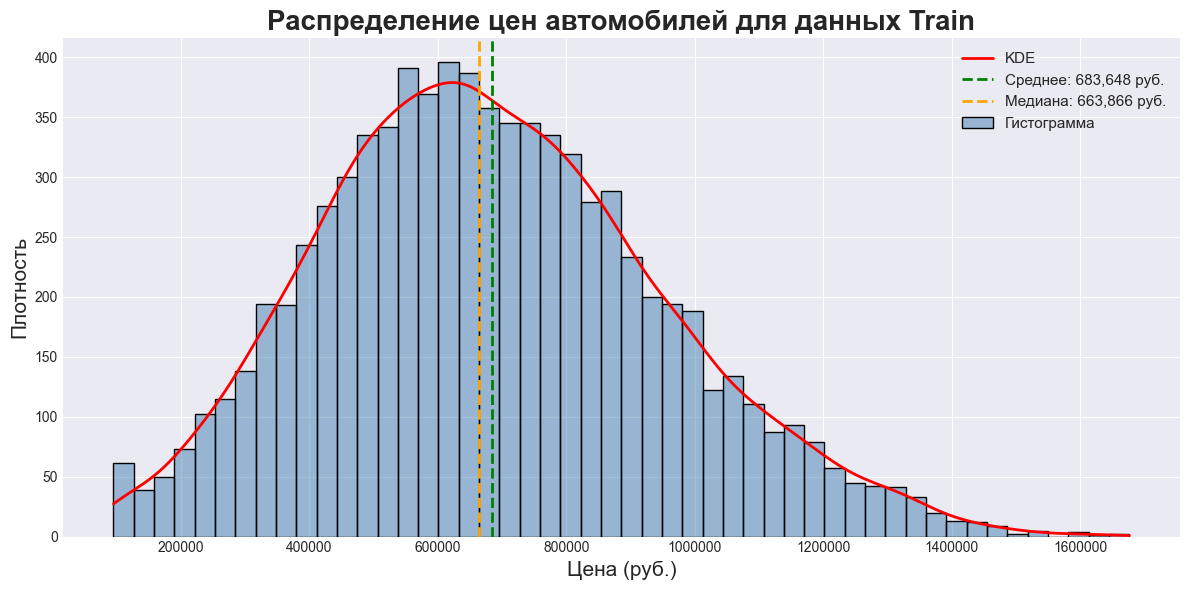

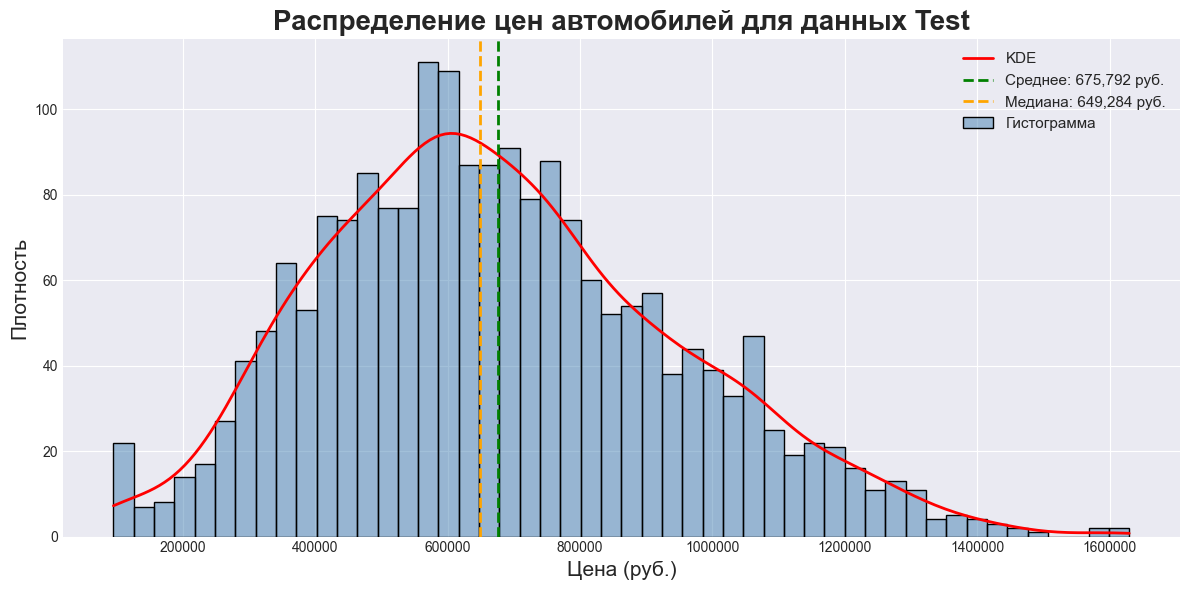

In [10]:
# Выводим распределение стоимости автомобиля
print_histplot(train_df, 'price_rub', 'Train')
print_histplot(test_df, 'price_rub', 'Test')

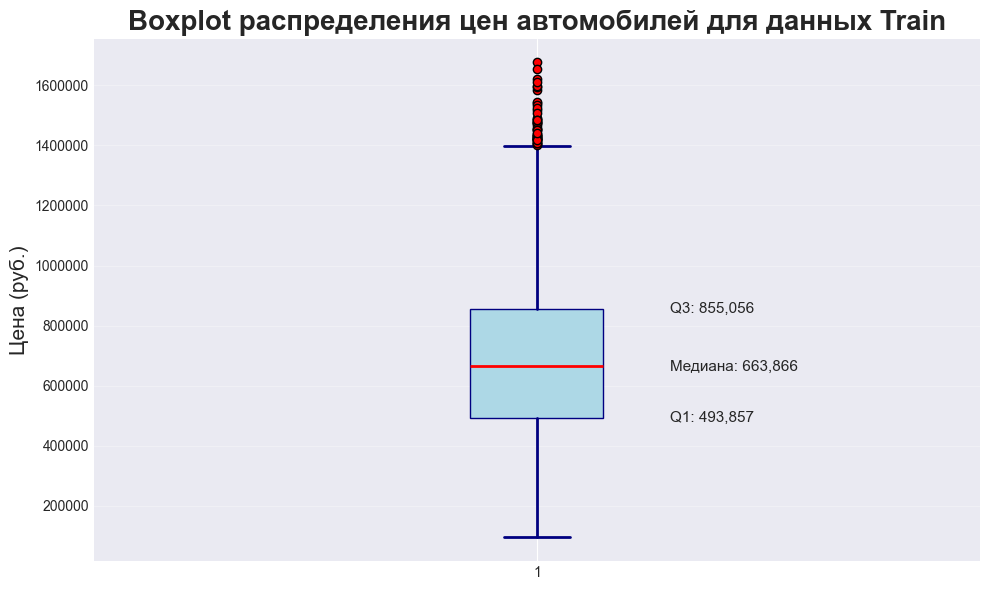

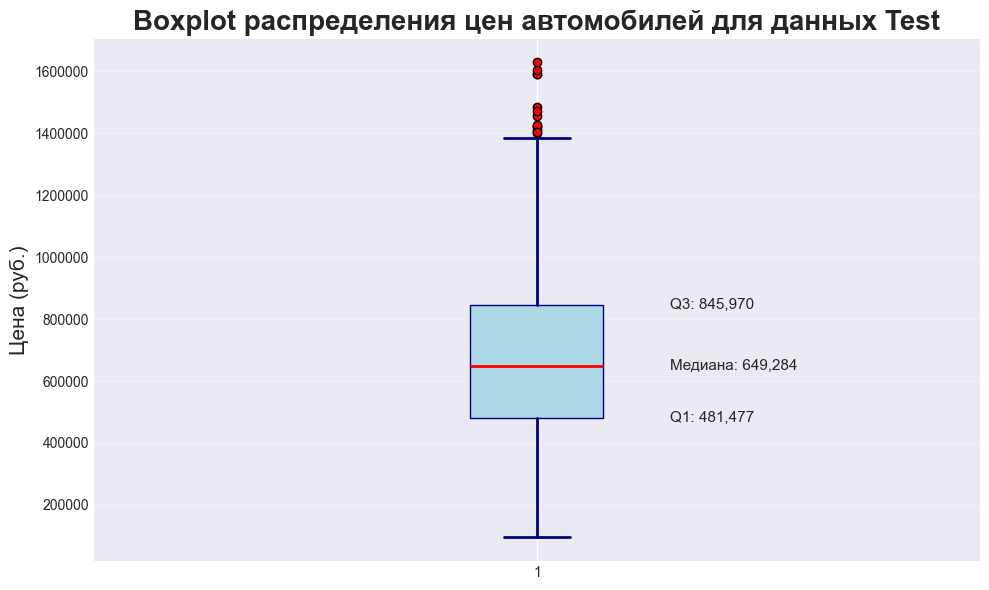

In [11]:
# Выводим boxplot стоимости автомобиля
print_boxplot(train_df, 'price_rub', 'Train')
print_boxplot(test_df, 'price_rub', 'Test')

### [2.2 Анализ числовых признаков <a id=2_2></a>](#content)

In [12]:
# Определяем числовые признаки
numeric_cols = train_df.select_dtypes(np.number).columns
print(*numeric_cols, sep='\n')

make_year
mileage_kmpl
engine_cc
owner_count
accidents_reported
price_rub


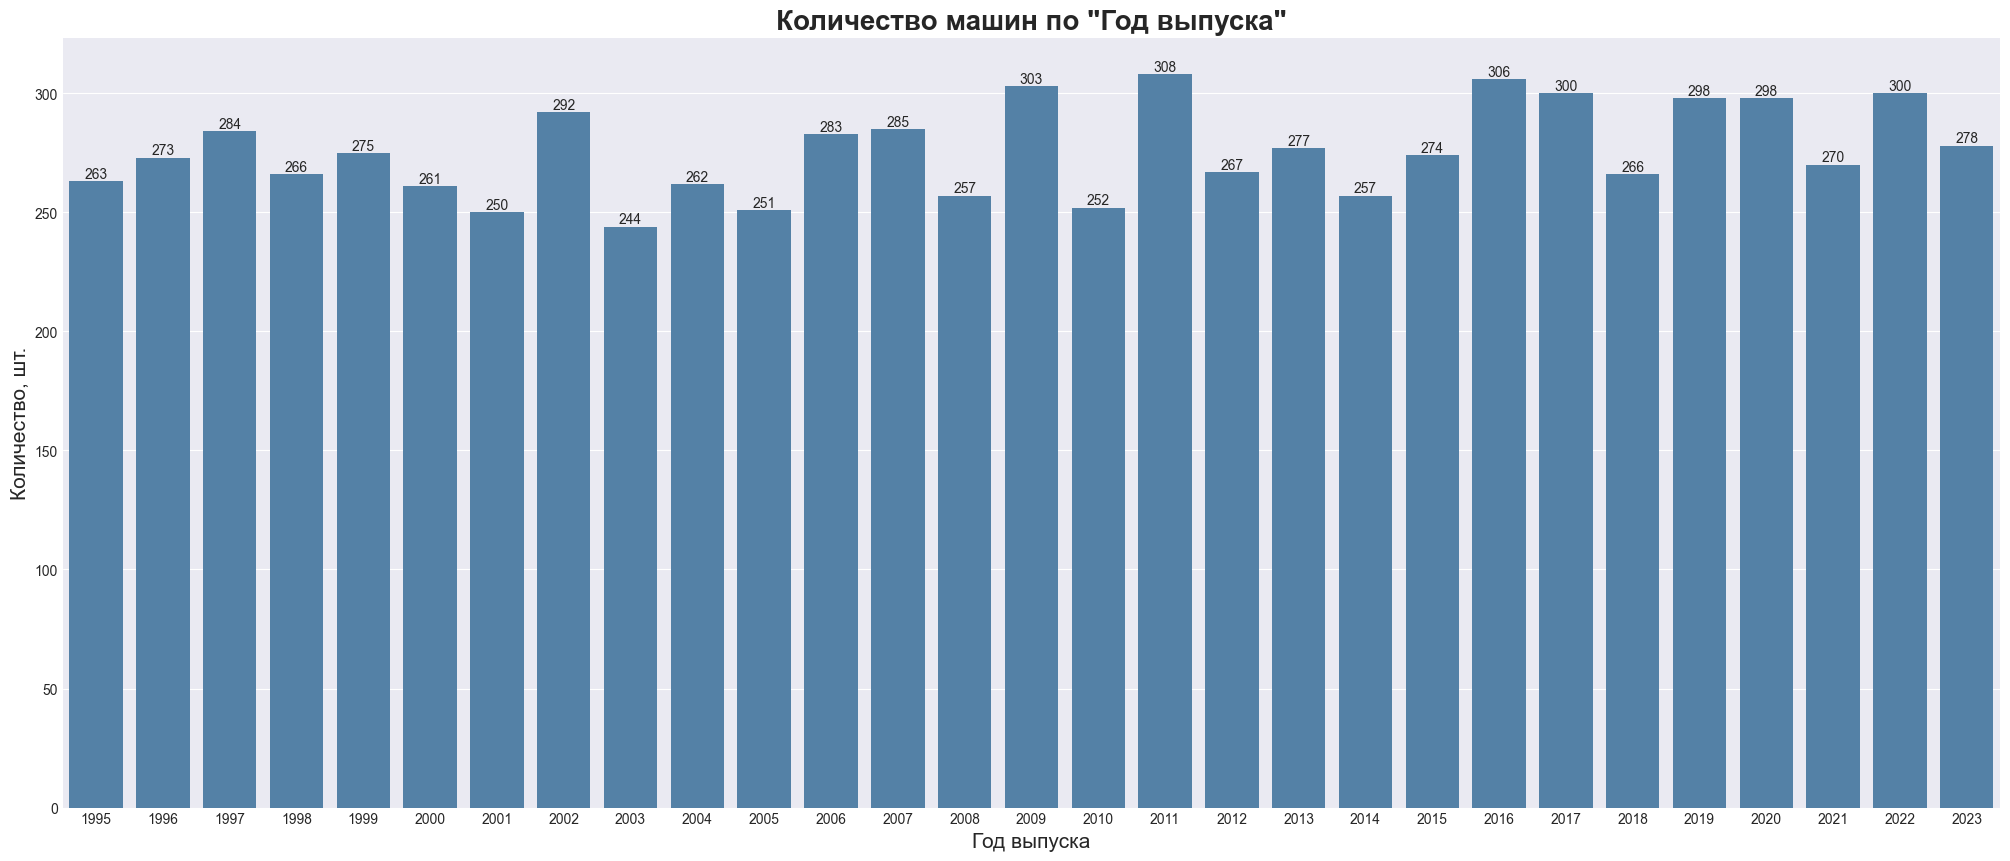

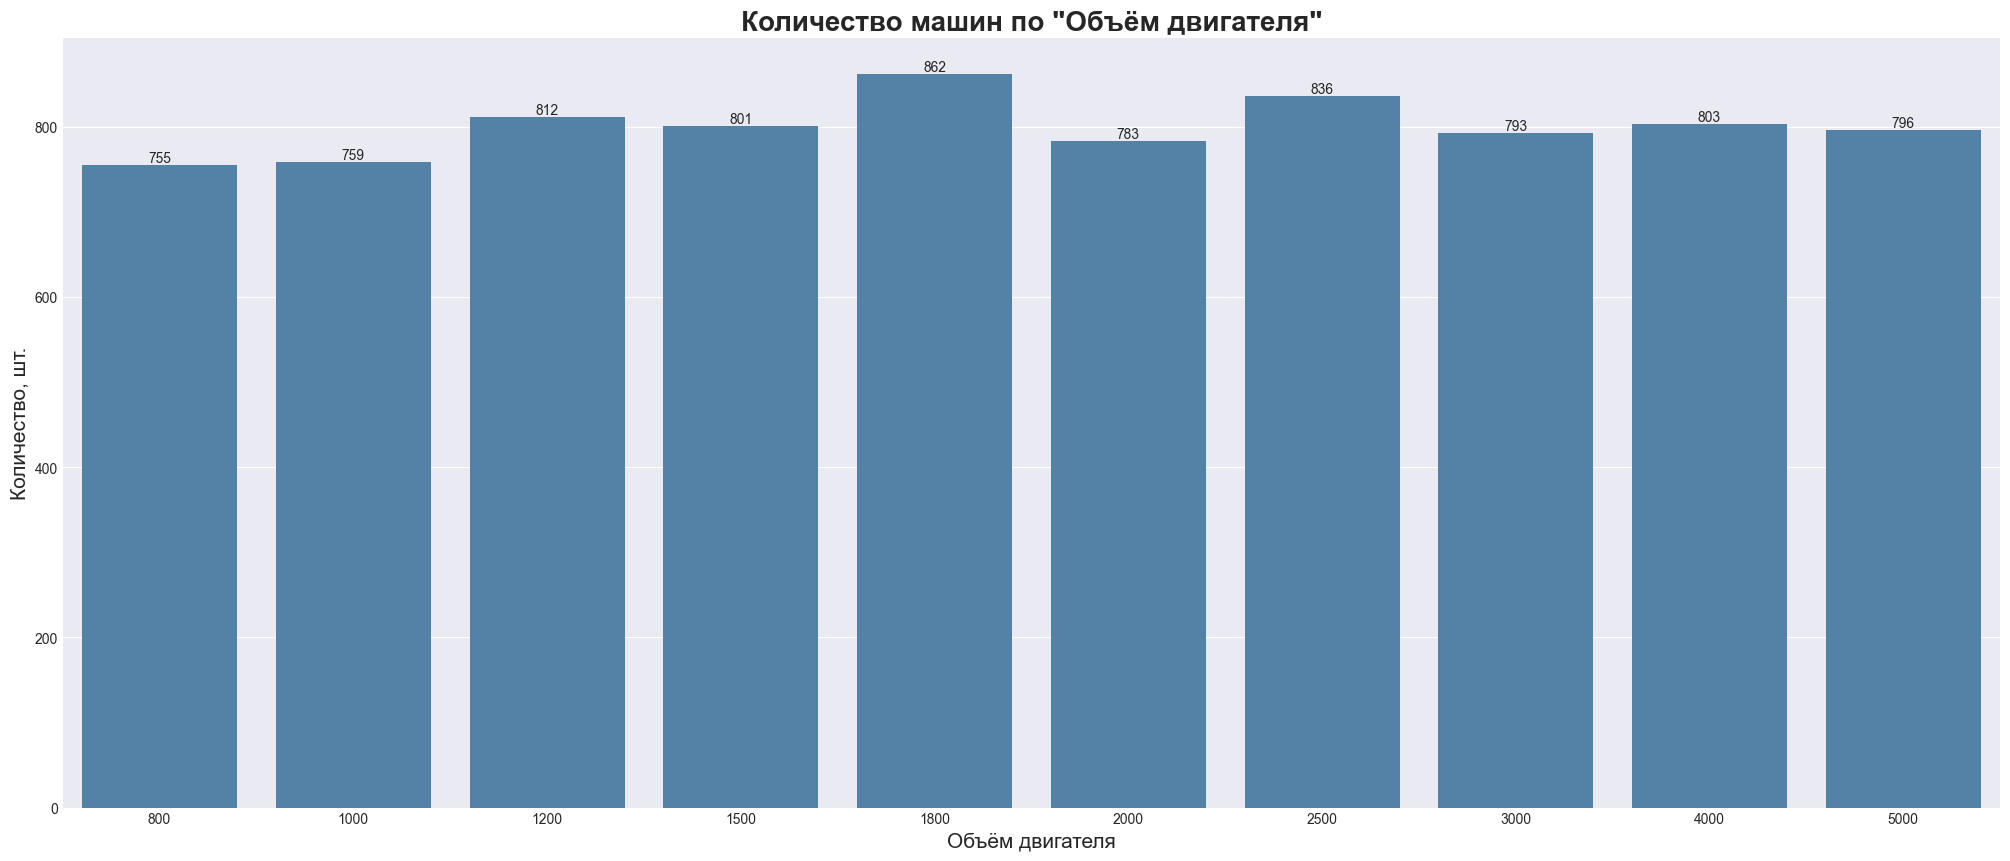

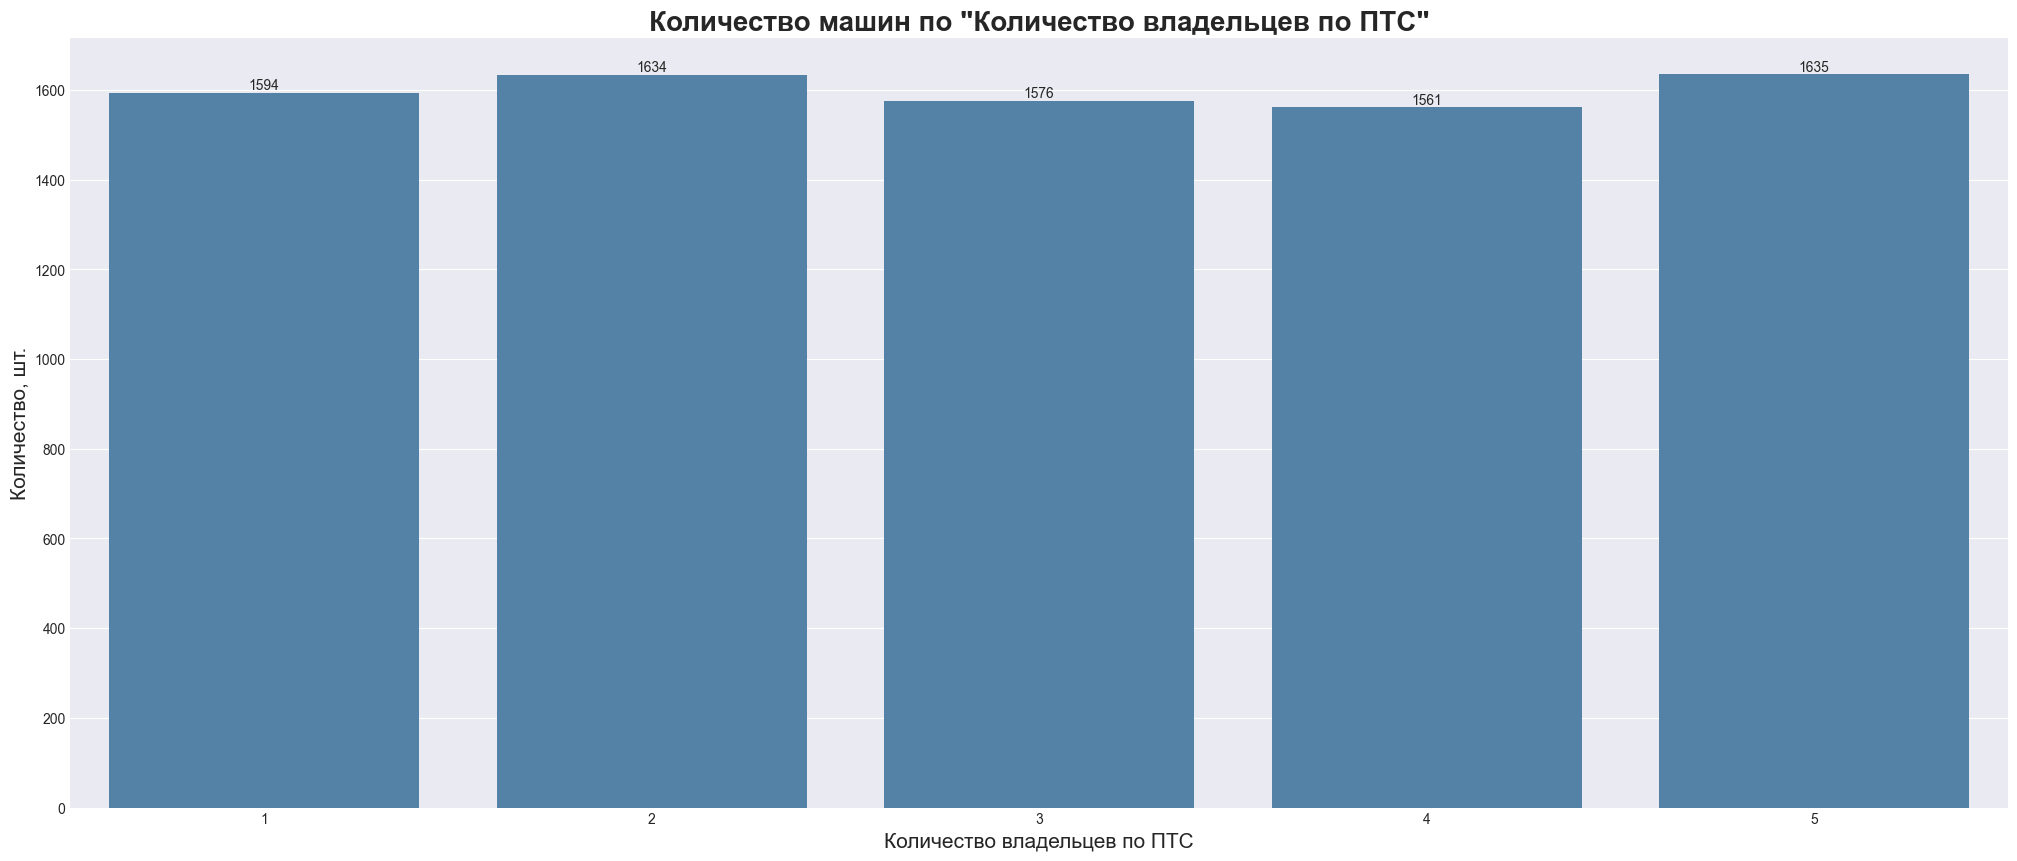

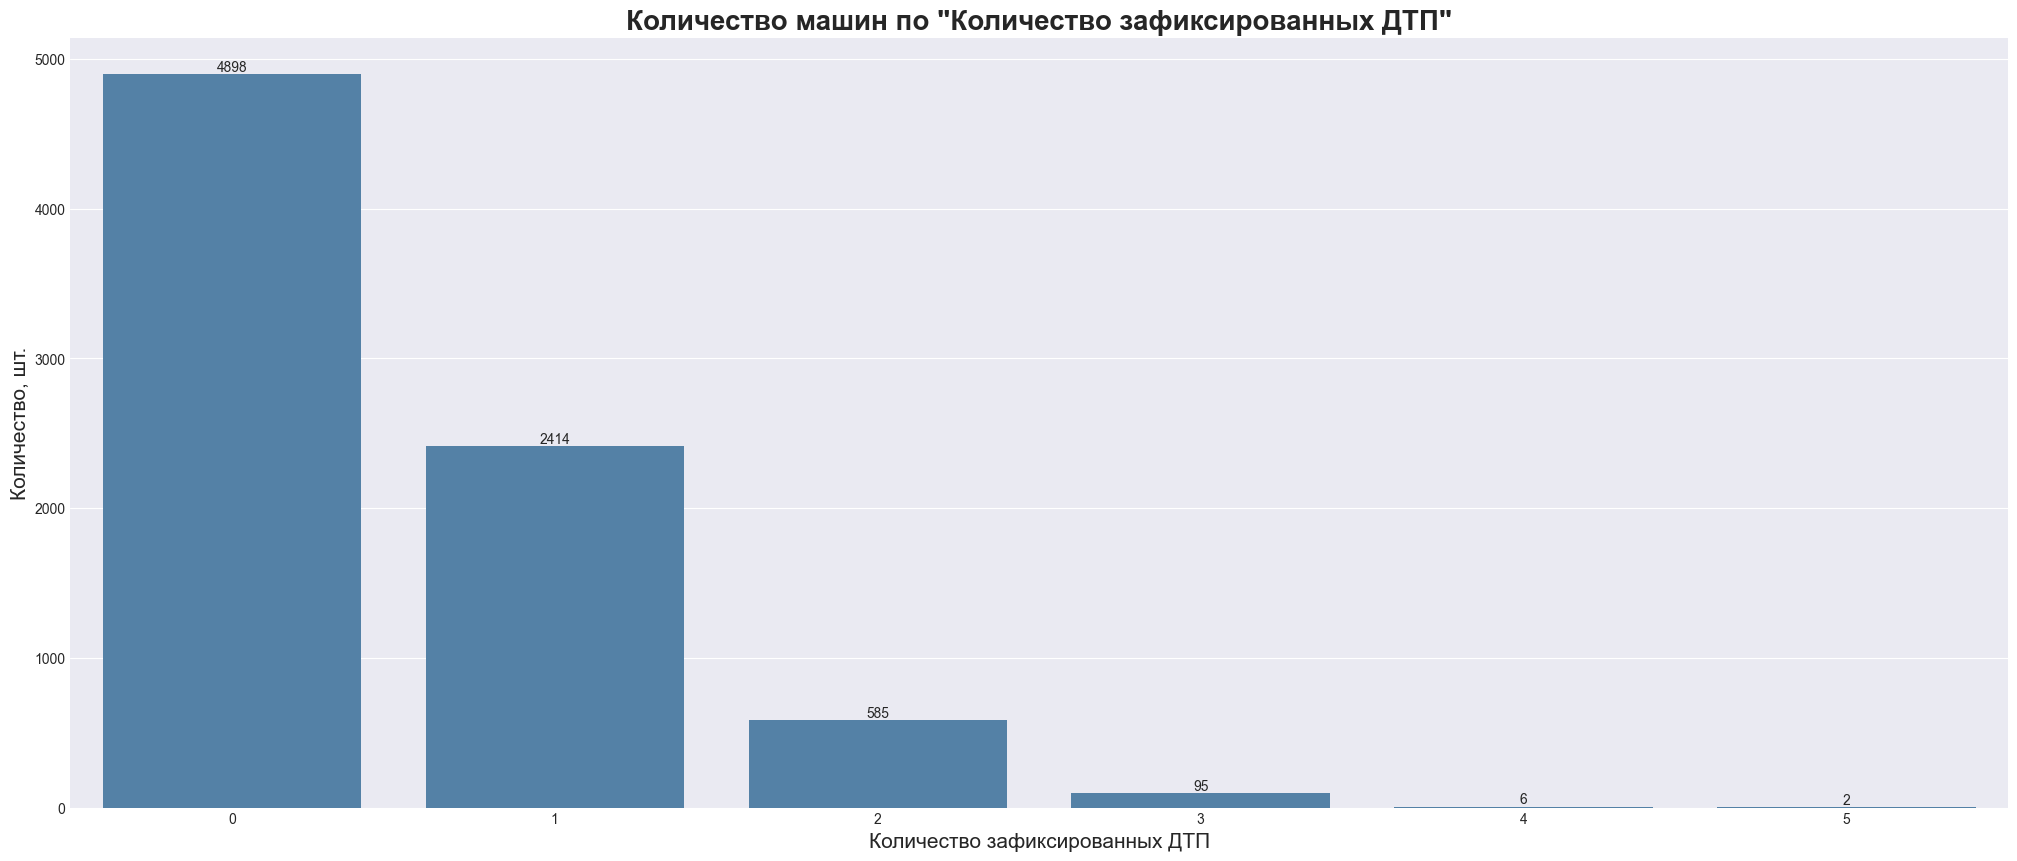

In [13]:
for col, name in [('make_year', 'Год выпуска'), ('engine_cc', 'Объём двигателя'), ('owner_count', 'Количество владельцев по ПТС'), ('accidents_reported', 'Количество зафиксированных ДТП')]:
   plt.figure(figsize=(25, 10))
   ax = sns.countplot(data=train_df, x=col, color='steelblue')
   for p in ax.patches:
      ax.annotate(f'{int(p.get_height())}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='bottom')

   plt.title(f'Количество машин по "{name}"', fontsize=20, fontweight='bold')
   plt.ylabel('Количество, шт.', fontsize=15)
   plt.xlabel(name, fontsize=15)
   plt.show()

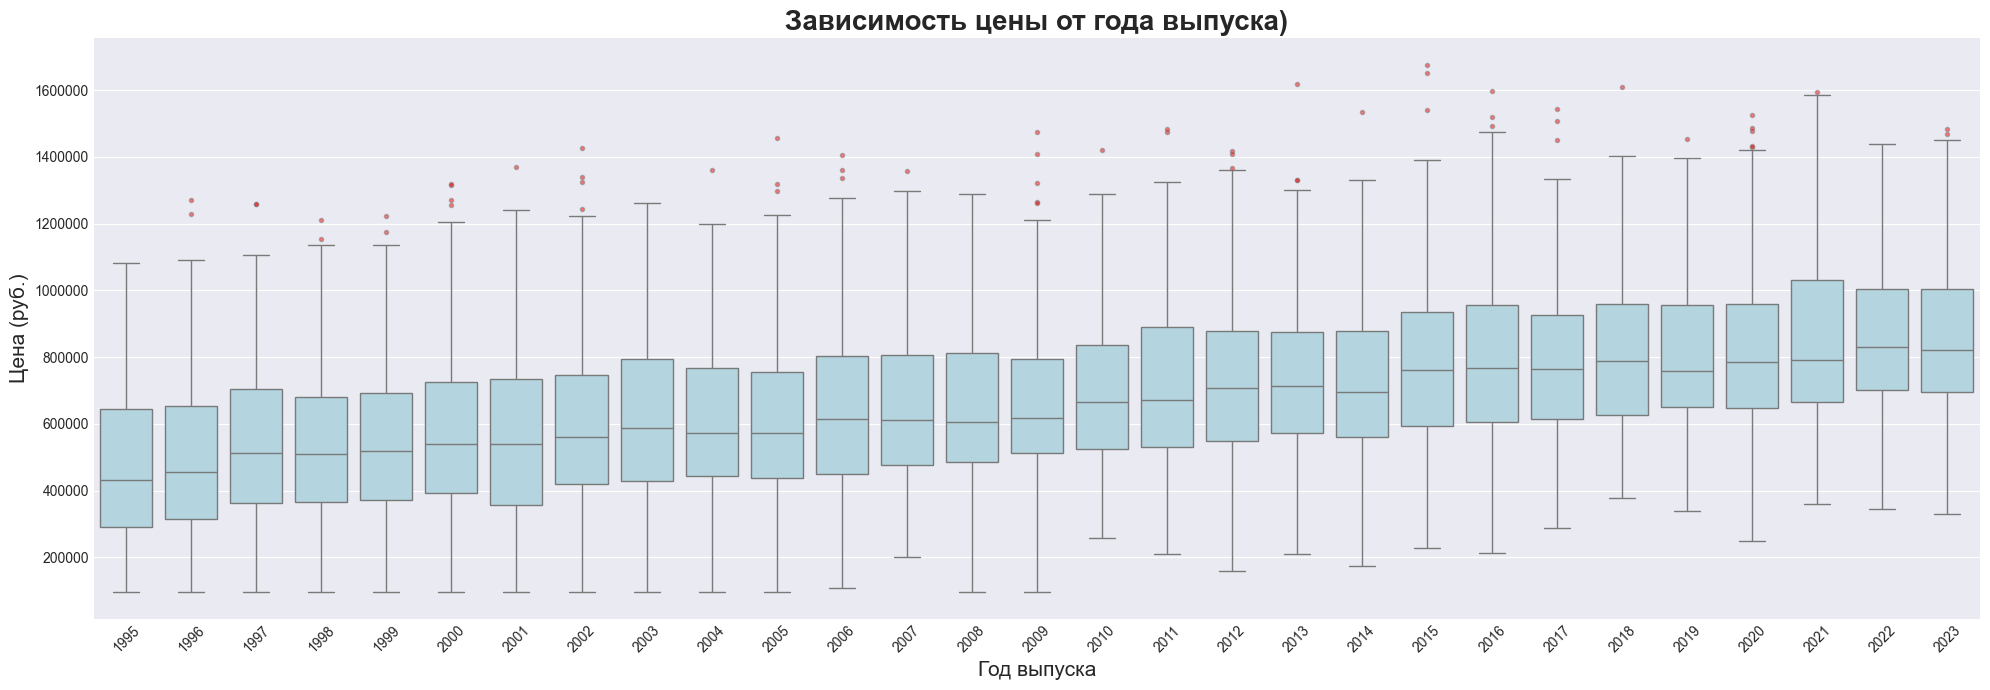

In [14]:
plt.figure(figsize=(20, 7))

# 1. Boxplot для визуализации распределения и выбросов по каждому году
sns.boxplot(
    data=train_df, 
    x='make_year', 
    y='price_rub',
    color='lightblue',
    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5), # Выбросы красными точками
    showfliers=True  # Важно видеть выбросы для EDA
)

# Настройка внешнего вида
plt.title('Зависимость цены от года выпуска)', fontsize=20, fontweight='bold')
plt.xlabel('Год выпуска', fontsize=15)
plt.ylabel('Цена (руб.)', fontsize=15)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### [2.3 Анализ категориальных признаков <a id=2_3></a>](#content)

Text(0, 0.5, 'Цена (руб.)')

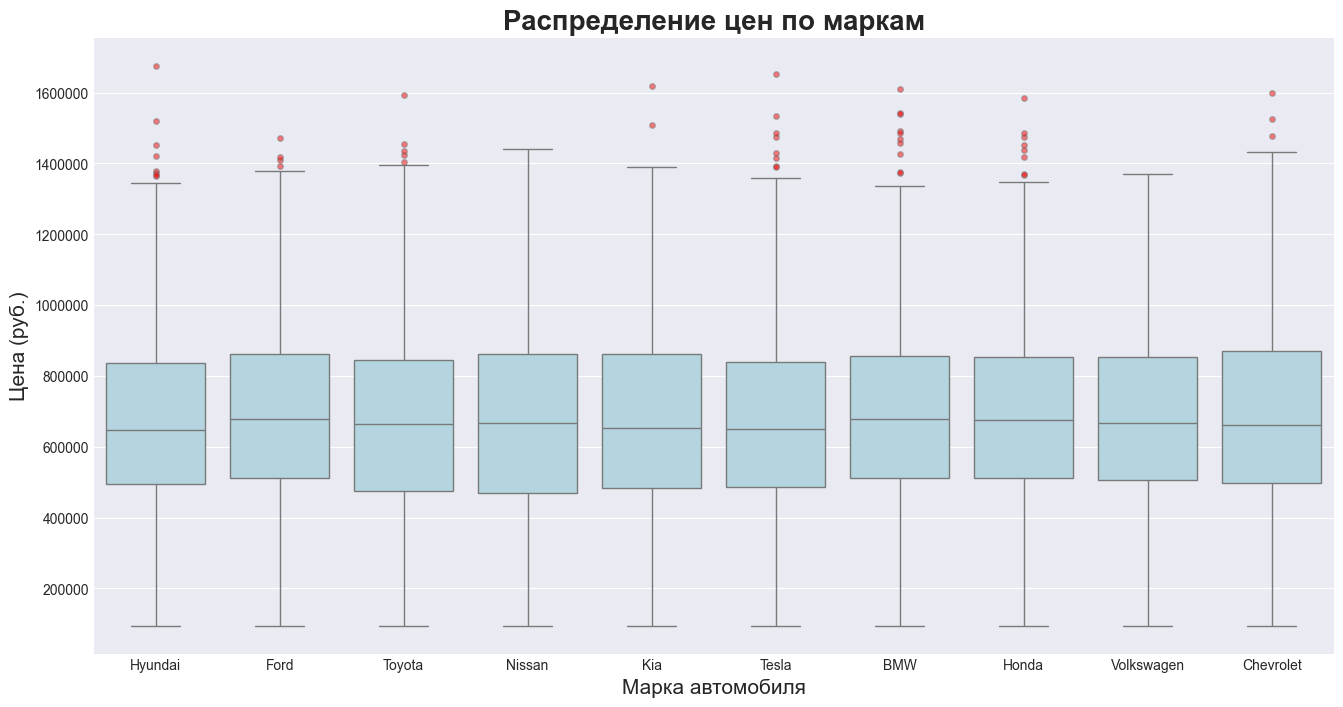

In [15]:
# График распределение цен по маркам
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=train_df,
    x='brand',
    y='price_rub',
    color='lightblue',
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5)
)

plt.title('Распределение цен по маркам', fontsize=20, fontweight='bold')
plt.xlabel('Марка автомобиля', fontsize=15)
plt.ylabel('Цена (руб.)', fontsize=15)

Text(0, 0.5, 'Цена (руб.)')

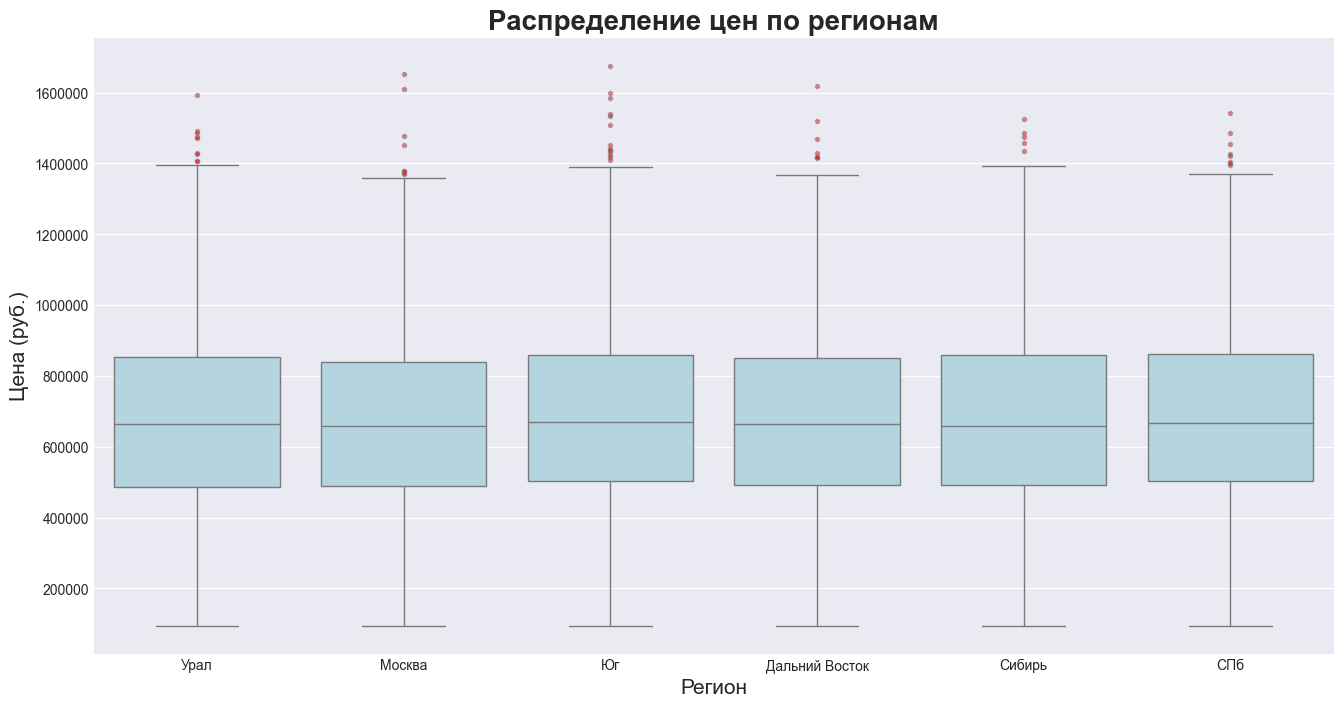

In [16]:
# График распределение цен по регионам
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=train_df, 
    x='region', 
    y='price_rub',
    color='lightblue',
    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5)
)

plt.title('Распределение цен по регионам', fontsize=20, fontweight='bold')
plt.xlabel('Регион', fontsize=15)
plt.ylabel('Цена (руб.)', fontsize=15)

### [2.4 Анализ корреляционной матрицы <a id=2_4></a>](#content)

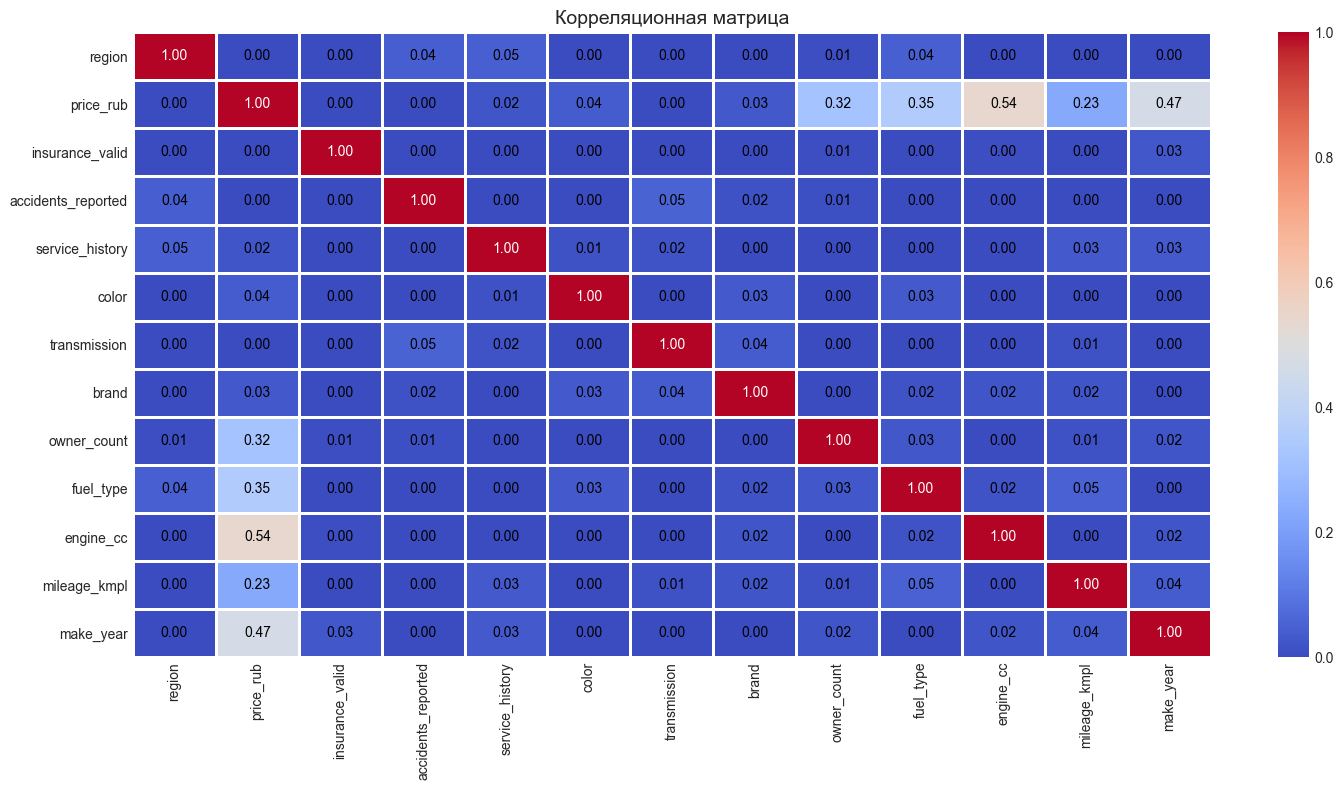

In [22]:
# Рассчитываем матрицу для всех признаков
phik_matrix = train_df.phik_matrix(interval_cols=numeric_cols)

# Визуализация матрицы
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1,
    title='Корреляционная матрица',
    figsize=(15, 8),
    color_map='coolwarm'
)

plt.show()

## [Этап 3. Предобработка данных <a id=3></a>](#content)